In [25]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [26]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [27]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

In [28]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [29]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True) # делит 50000 на батчи по 8

Посмотрим как выглядит семпл

In [30]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

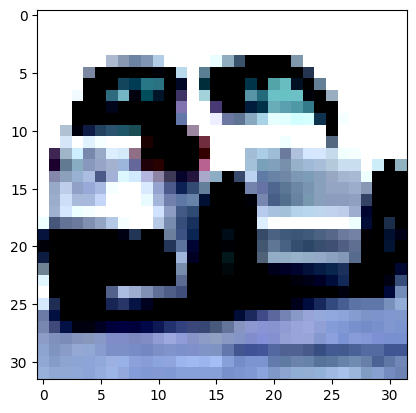

In [31]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0) # берем из батча первое изображение и меняем каналы местами для правильного отображения
plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [32]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1) # 32 -> 30 + 2 (padding)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1) # 30 -> 28 + 2 (padding)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1) # 28 -> 26 + 2 (padding)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # 26 -> 13

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # 32 -> 32 -> 16
        x = self.pool(F.relu(self.conv2(x))) # 16 -> 16 -> 8
        x = self.pool(F.relu(self.conv3(x))) # 8 -> 8 -> 4

        x = x.view(-1, 64 * 4 * 4) # выпрямляем

        x = F.relu(self.fc1(x)) # прогоняем x сквозь матрицу весов
        x = self.fc2(x) # по второму кругу

        return x

Посмотрим, что она выдаст

In [33]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [34]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

In [35]:
class Trainer:
    def __init__(self, config, model=BasicCNN(), transform=None):
        self.config = config
        self.transform = transform

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.model = model.to(self.device)

        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        self.val_metric = []
        self.train_metric = []
        self.test_metric = []

        self.setup_dataloaders()

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(list(range(len(train_dataset_full))), test_size=self.config['test_size'], random_state=42, shuffle=True)
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(dataset=train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def run(self):
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()

            self.train_metric.append({
                'epoch' : epoch + 1,
                'loss' : train_loss,
                'acc' : train_acc
            })

            self.val_metric.append({
                'epoch' : epoch + 1,
                'loss' : val_loss,
                'acc' : val_acc
            })

            print(f'Epoch {epoch + 1} / {self.config['num_epochs']}', train_loss, val_loss, val_acc)

            test_loss, test_acc = self.test_step() # дальше предлагают построить график сравнения test, поэтому теперь тестируем под конец каждой эпохи

            self.test_metric.append({
                'epoch' : epoch + 1,
                'loss' : test_loss,
                'acc' : test_acc
            })

            print(f'Test loss {test_loss}, test acc {test_acc}')

    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()

            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100

        return total_loss, train_acc

    def val_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.val_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.val_loader)
        val_acc = correct / total_samples * 100

        return total_loss, val_acc

    def test_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.test_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.test_loader)
        test_acc = correct / total_samples * 100

        return total_loss, test_acc

In [36]:
trainer_1 = Trainer(config, transform=transform)

In [37]:
trainer_1.run()

100%|██████████| 79/79 [00:02<00:00, 31.61it/s]


Epoch 1 / 10 1.6105791551236528 1.3792414604863035 50.029999999999994


100%|██████████| 79/79 [00:03<00:00, 25.05it/s]


Test loss 1.382837470573715, test acc 49.81


100%|██████████| 79/79 [00:02<00:00, 26.89it/s]


...

Test loss 1.0362675197516815, test acc 64.18


100%|██████████| 79/79 [00:02<00:00, 29.34it/s]


Epoch 10 / 10 0.8023060996311541 1.0011019269122352 65.60000000000001


100%|██████████| 79/79 [00:03<00:00, 25.64it/s]

Test loss 1.035365745236602, test acc 64.75


# ResNet-18

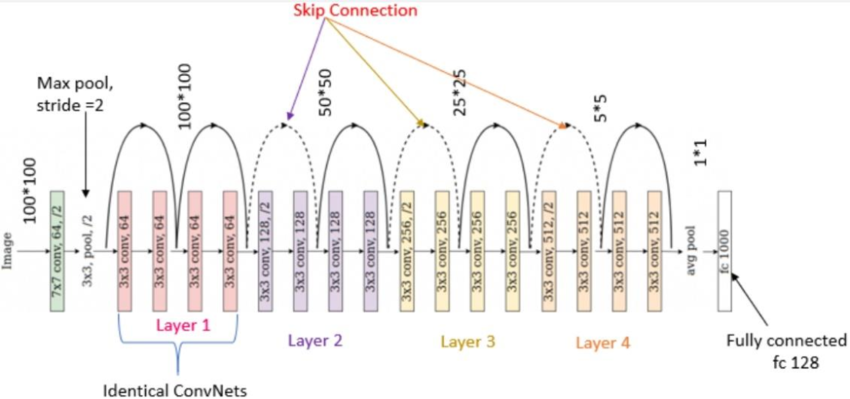

In [38]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1) # conv1 previously
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        if self.downsample is not None:
            identity = self.downsample(identity)

        # Применить свертки + skip connection
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        out = x + identity # проверить совпадение размера
        out = F.relu(out)

        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Сделать 4 слоя по 2 блока по картинке
        self.layer1 = self.make_layer(64, 2)
        self.layer2 = self.make_layer(128, 2, 2)
        self.layer3 = self.make_layer(256, 2, 2)
        self.layer4 = self.make_layer(512, 2, 2)

        # на картинке есть, дописываю :sob:
        self.fc1 = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, blocks, stride=1):
        blocks_array = []

        # first block with skip connection or nay
        downsample = None
        if (self.in_channels != out_channels or stride != 1):
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
        blocks_array.append(ResNetBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for i in range(1, blocks):
            blocks_array.append(ResNetBlock(out_channels, out_channels))

        return nn.Sequential(*blocks_array)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)

        return x

$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

In [39]:
trainer_2 = Trainer(config, model=ResNet18(), transform=transform)

In [40]:
trainer_2.run()

100%|██████████| 79/79 [00:03<00:00, 20.94it/s]


Epoch 1 / 10 1.923391319311465 1.6144726955437962 41.74


100%|██████████| 79/79 [00:03<00:00, 23.27it/s]


Test loss 1.6181288791608206, test acc 40.9


100%|██████████| 79/79 [00:03<00:00, 26.14it/s]


...

Test loss 0.866171787811231, test acc 74.5


100%|██████████| 79/79 [00:03<00:00, 26.11it/s]


Epoch 10 / 10 0.2229625022592255 0.9628269212155403 74.45


100%|██████████| 79/79 [00:03<00:00, 22.89it/s]

Test loss 0.9746587087836447, test acc 73.98


In [41]:
def create_plots(trainer, epochs, model, color, axs):
  train_acc = [i['acc'] for i in trainer.train_metric]
  train_loss = [i['loss'] for i in trainer.train_metric]

  val_acc = [i['acc'] for i in trainer.val_metric]
  val_loss = [i['loss'] for i in trainer.val_metric]

  test_acc = [i['acc'] for i in trainer.test_metric]
  test_loss = [i['loss'] for i in trainer.test_metric]
  #print(train_acc)
  #print(train_loss)

  #print(val_acc)
  #print(val_loss)

  #print(test_acc)
  #print(test_loss)

  axs[0][0].plot(epochs, train_acc, label=model, color=color, linewidth=2)
  axs[0][1].plot(epochs, val_acc, label=model, color=color, linewidth=2)
  axs[0][2].plot(epochs, test_acc, label=model, color=color, linewidth=2)

  axs[1][0].plot(epochs, train_loss, label=model, color=color, linewidth=2)
  axs[1][1].plot(epochs, val_loss, label=model, color=color, linewidth=2)
  axs[1][2].plot(epochs, test_loss, label=model, color=color, linewidth=2)


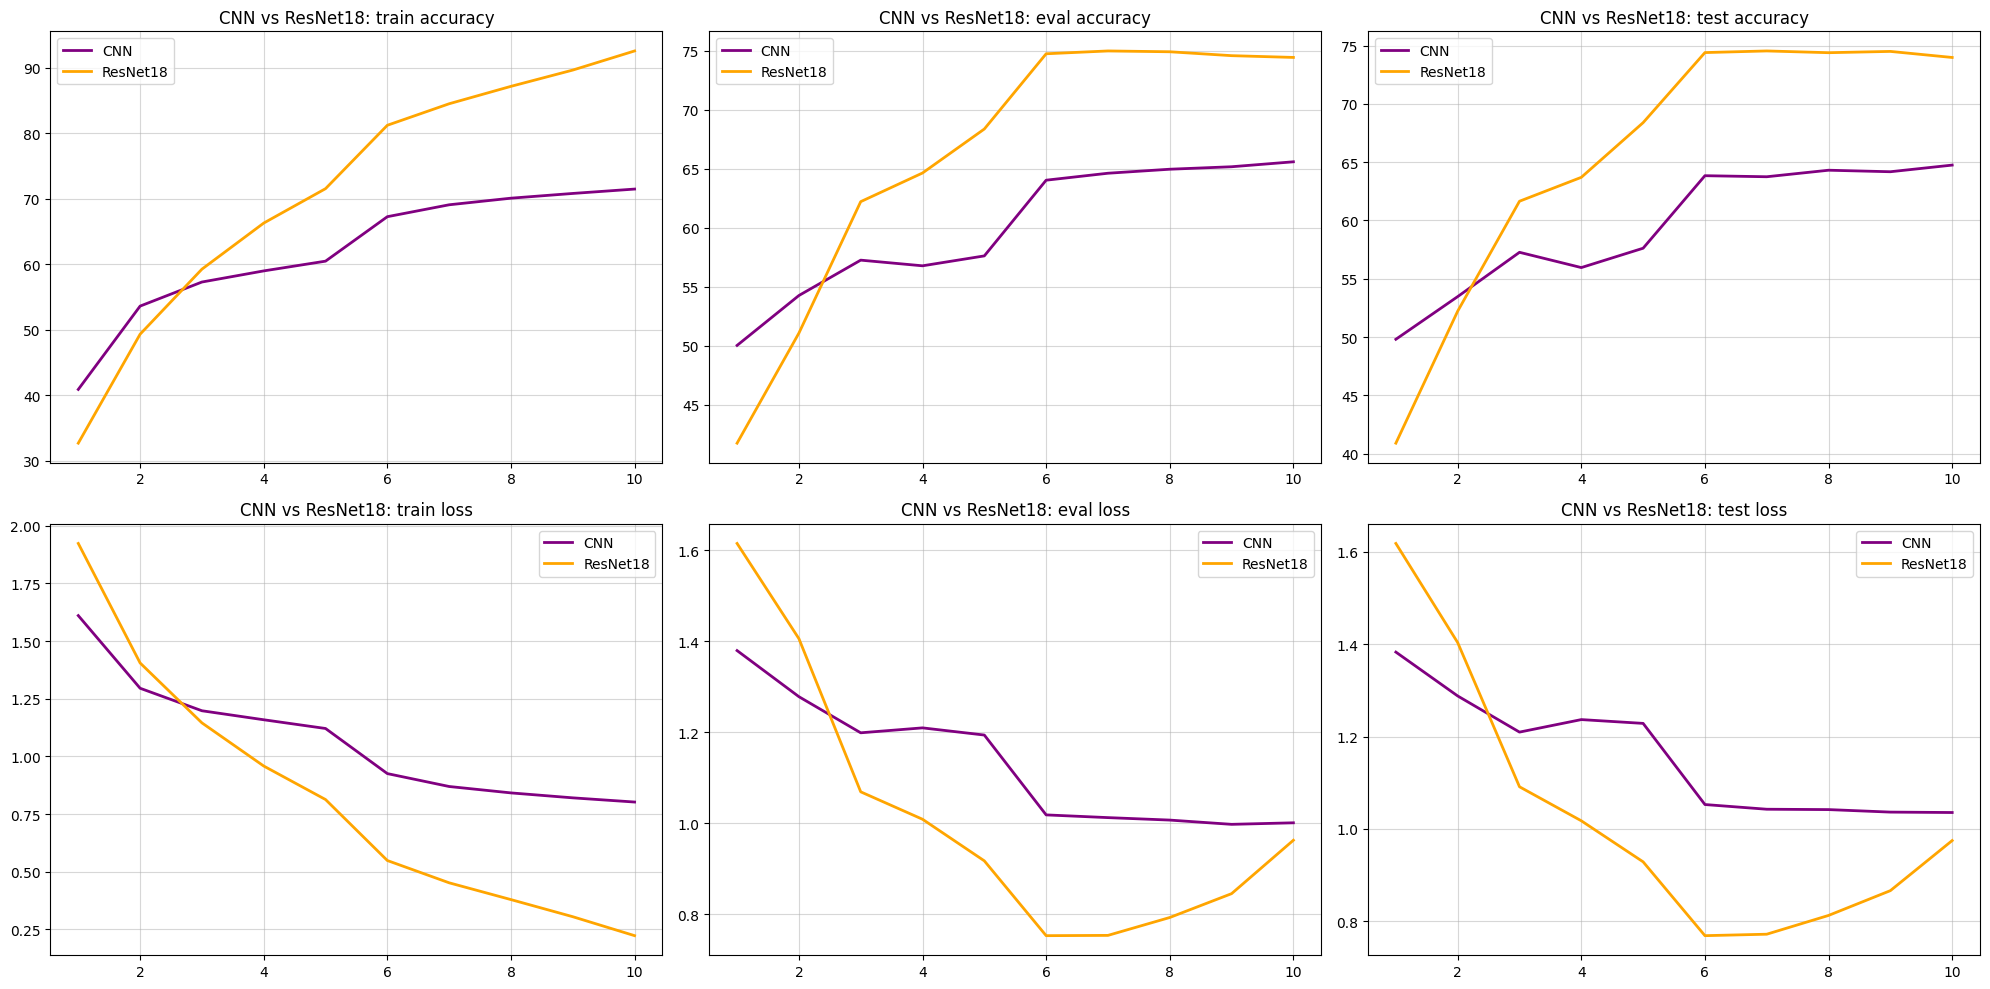

In [42]:
# Запустить Trainer с ResNet18 на 10 эпох и сранивать графики train / val / test точности с базовой CNN

fig, axs = plt.subplots(2, 3, figsize=(20, 10))
epochs = [i + 1 for i in range(config['num_epochs'])]
plt.rcParams['image.cmap'] = 'gray'

create_plots(trainer_1, epochs, 'CNN', 'purple', axs)
create_plots(trainer_2, epochs, 'ResNet18', 'orange', axs)

axs[0][0].set_title('CNN vs ResNet18: train accuracy')
axs[0][1].set_title('CNN vs ResNet18: eval accuracy')
axs[0][2].set_title('CNN vs ResNet18: test accuracy')

axs[1][0].set_title('CNN vs ResNet18: train loss')
axs[1][1].set_title('CNN vs ResNet18: eval loss')
axs[1][2].set_title('CNN vs ResNet18: test loss')

for i in range(2):
  for j in range(3):
    axs[i][j].legend()
    axs[i][j].grid(alpha=0.5)
plt.tight_layout()
plt.show()